# Transpilation scaling of the purity-amplification circuit

**Resource estimate for the cyclic Quantum Purification Algorithm (QPA) of [arXiv:2409.18167](https://arxiv.org/abs/2409.18167)**

This notebook answers two questions raised in review of the paper:

> **Q1.** If one takes the quantum circuits from the paper and transpiles them, how do their
> **depth** and **gate count** grow with the number of qubits in $\rho$ and with $m$?
> How rapidly does one reach **5k–15k gates**?
>
> **Q2.** Are the circuits known to the point of performing a transpilation — i.e. is it known
> how to represent $F$ and $P$ (Fig. 3) in terms of **1- and 2-qubit gates**?

Both questions are answered concretely below, transpiling the circuits this repository actually
builds against an IBM heavy-hex device (`FakeBrisbane`, 127 qubits) and against the `ibm_boston`
native basis with all-to-all connectivity (an early-FTQC / no-routing lower bound).

The short answers:

* **Q2 — yes, fully.** In OQPA's weak-Schur-sampling realization, $F$ reduces to a **Hadamard** and
  the controlled-$P$ reduces to **controlled-SWAP (Fredkin)** networks; the uncontrolled $P$ is a
  **SWAP** network. All decompose into $\{cz, r_z, s_x, x\}$ with known, small constant cost
  (CSWAP $\to$ 7 two-qubit gates, SWAP $\to$ 3).
* **Q1 — linearly, and quickly.** The intrinsic two-qubit count grows as $\approx 3.5\,k\,T\,(N-1)$.
  A minimal $m{=}2$ demonstration is $\sim\!130$ gates (NISQ-trivial), but realistic copy counts
  ($N\sim15$–$21$) at $T{=}3$ reach the **5k-gate** regime, and on a fixed-connectivity device the
  **qubit budget (127)**, not the gate count, becomes the binding constraint before 15k.


## What are $\rho$ and $m$ in *this* repository?

The paper is written for a general qudit state $\rho$ and an amplification order $m$ (so that
$\rho^m \propto (1-\lambda)^m|\psi\rangle\langle\psi| + \lambda^m\rho_{\rm err}^m \to |\psi\rangle\langle\psi|$).
OQPA implements the **cyclic** variant of this protocol with three knobs:

| Paper symbol | OQPA knob | Meaning in this repo |
|---|---|---|
| qubits in $\rho$ | **`k`** | Each noisy copy of $\rho$ lives on a **`k`-qubit data register** (qudit dimension $d=2^k$). "Number of qubits in $\rho$" $\equiv$ `k`. |
| amplification order $m$ | **`N`** (= `n_registers`) and **`T`** (= `n_trials`) | $m$ is *not* a single knob here. The circuit coherently combines **`N` copies** of $\rho$ (odd, $N=2i{+}1$) and applies **`T` rounds** of Schur-test + cyclic-rotation. More copies / more rounds $\Rightarrow$ higher effective $m$ $\Rightarrow$ stronger suppression of the $\lambda$ error term. |

So the OQPA register layout is `N` data registers of `k` qubits each ($N\cdot k$ data qubits),
plus $(N-1)/2$ ancillas for the parallel swap tests. One register is the **reserve**; after the
protocol its reduced state $\rho'$ is the purified output (Fig. 3, "Trace-out").

**Mapping $m$:** the minimal non-trivial amplification, $m{=}2$ — a single comparison of two
copies — is one swap test, i.e. **`N=3, T=1`** here (registers `R1,R2` are Schur-tested, `R3` is
the reserve returned as $\rho'$). The reviewer's suggestion to "get away with $m{=}2$ for
SQD" therefore corresponds to the smallest, cheapest setting of this circuit.


## Mapping Fig. 3 ($F$, $P$, GQPE) onto the OQPA circuit

Figure 3 of the paper performs **weak Schur sampling via Generalized Quantum Phase Estimation
(GQPE)**: a control register is Fourier-transformed by $F$, a *controlled* power of the permutation
$P$ acts on the copies of $\rho$, and $F^{-1}$ is applied before measurement; corrections use the
inverse GQPE, and the unwanted registers are traced out.

OQPA realizes this with the **swap-test** specialization (the $d{=}2$, two-copy GQPE primitive):

| Fig. 3 block | OQPA realization | Native cost |
|---|---|---|
| $F$ (Fourier transform on a 1-qubit control) | **Hadamard** on the swap-test ancilla | 1-qubit gate |
| controlled-$P$ (controlled permutation of copies) | **controlled-SWAP** (Fredkin) between two `k`-qubit registers — i.e. the **Schur / swap test** `H · CSWAP^k · H` | $k$ Fredkin gates |
| $P$ (uncontrolled permutation of copies) | **cyclic rotation** of the surviving registers, built from **SWAP** gates | $(N{-}1)\,k$ SWAPs / round |

The relevant source is `experiments/dynamic_transpilation/qpa_engine.py`
(`apply_schur_test`, `apply_cyclic_rotation`, and `UnrolledStrategy.build_longest_path`). Below we
rebuild the **longest path** (every swap test passes — the heaviest branch, matching the coherent
circuit of Fig. 3) in a self-contained way so the notebook has no `qiskit_aer` dependency.


In [1]:
# === repo-root bootstrap ===
# Locate the repository root (the directory containing `core/`), chdir there, and
# put it on sys.path so `shared_data/...` output paths resolve from any launch dir.
import os, sys
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeBrisbane
import qiskit
print("qiskit", qiskit.__version__)

OUTDIR = os.path.join("shared_data", "experiment_results", "scaling")
os.makedirs(OUTDIR, exist_ok=True)
print("Outputs ->", OUTDIR)

Repo root: /Users/henryzou/Documents/GitHub/OQPA
qiskit 2.3.0
Outputs -> shared_data/experiment_results/scaling


## The circuit builder

`build_qpa(k, N, T)` reproduces `UnrolledStrategy.build_longest_path` from `qpa_engine.py`: the
all-swap-tests-pass branch, which is the deepest static circuit and the right worst case for a
resource estimate. Each round does $(N-1)/2$ parallel Schur tests (`H · CSWAP^k · H`), records each
ancilla and resets it (so a single ancilla pool of size $(N-1)/2$ is reused across rounds — keeping
the qubit count independent of $T$), then cyclically rotates all $N$ registers. The reserve register
is measured at the end.

In [2]:
def build_qpa(k, N, T):
    """Longest-path (all-pass) cyclic-QPA circuit.

    k : qubits per copy of rho        (paper: qubits in rho)
    N : number of copies, odd 2i+1    (paper: amplification order m, with T)
    T : number of Schur-test rounds   (paper: amplification order m, with N)

    Mirrors UnrolledStrategy.build_longest_path in
    experiments/dynamic_transpilation/qpa_engine.py.
    """
    assert N % 2 == 1, "N (n_registers) must be odd (2i+1)"
    data = [QuantumRegister(k, f"R{i+1}") for i in range(N)]
    n_pairs = (N - 1) // 2
    anc = QuantumRegister(n_pairs, "anc")                 # reused pool (reset each round)
    cr_anc = ClassicalRegister(T * n_pairs, "schur")      # swap-test outcomes
    cr_out = ClassicalRegister(k, "readout")              # purified reserve rho'
    qc = QuantumCircuit(*data, anc, cr_anc, cr_out)

    m = 0
    for t in range(T):
        # (N-1)/2 parallel Schur tests = controlled-P  (F = H ; controlled-P = CSWAP^k)
        for i in range(n_pairs):
            a, ra, rb = anc[i], data[2 * i], data[2 * i + 1]
            qc.h(a)
            for b in range(k):
                qc.cswap(a, ra[b], rb[b])
            qc.h(a)
            qc.measure(a, cr_anc[m]); m += 1
            qc.reset(a)
        # cyclic rotation of all N registers = uncontrolled P (longest path: all survive)
        for b in range(k):
            for j in range(N - 1, 0, -1):
                qc.swap(data[j][b], data[j - 1][b])
    qc.measure(data[-1], cr_out)                           # trace-out: keep reserve
    return qc

# qubit / logical-gate accounting (independent of transpilation)
def logical_counts(k, N, T):
    n_pairs = (N - 1) // 2
    return dict(
        data_qubits=N * k,
        ancillas=n_pairs,
        total_qubits=N * k + n_pairs,
        fredkin=k * T * n_pairs,         # controlled-P gates
        swaps=(N - 1) * k * T,           # uncontrolled-P gates
    )

ex = build_qpa(k=1, N=3, T=1)            # minimal m=2 demo
print("Minimal m=2 demo (k=1, N=3, T=1):", logical_counts(1, 3, 1))
print(ex.draw(output="text", fold=120))

Minimal m=2 demo (k=1, N=3, T=1): {'data_qubits': 3, 'ancillas': 1, 'total_qubits': 4, 'fredkin': 1, 'swaps': 2}
                                   
       R1: ──────X───────X─────────
                 │       │         
       R2: ──────X───X───X─────────
                 │   │     ┌─┐     
       R3: ──────┼───X─────┤M├─────
           ┌───┐ │ ┌───┐┌─┐└╥┘     
      anc: ┤ H ├─■─┤ H ├┤M├─╫──|0>─
           └───┘   └───┘└╥┘ ║      
  schur: 1/══════════════╩══╬══════
                         0  ║      
readout: 1/═════════════════╩══════
                            0      


## Q2 — Are $F$ and $P$ known to the gate level?

Yes. Transpiling the three primitives to the `ibm_boston` native basis $\{cz, r_z, s_x, x, id\}$
gives exact, constant decompositions. There is no unknown or "black-box" block in the circuit.

In [3]:
BOSTON_BASIS = ["cz", "rz", "sx", "x", "id"]   # ibm_boston native gate set
pm_basis = generate_preset_pass_manager(optimization_level=3, basis_gates=BOSTON_BASIS,
                                        seed_transpiler=1)

def decompose(label, qc):
    t = pm_basis.run(qc)
    ops = dict(t.count_ops())
    twoq = ops.get("cz", 0)
    print(f"{label:32s} 2q(cz)={twoq:2d}  depth={t.depth():2d}  ops={ops}")

qc = QuantumCircuit(1); qc.h(0);            decompose("F  =  Hadamard", qc)
qc = QuantumCircuit(2); qc.swap(0, 1);      decompose("P  =  SWAP (one register pair)", qc)
qc = QuantumCircuit(3); qc.cswap(0, 1, 2);  decompose("controlled-P = CSWAP (Fredkin)", qc)

print("\nConclusion: F -> 1 H; SWAP -> 3 two-qubit gates; CSWAP -> 7 two-qubit gates.")
print("Every block of Fig. 3 is fully specified in 1- and 2-qubit gates.")

F  =  Hadamard                   2q(cz)= 0  depth= 3  ops={'rz': 2, 'sx': 1}
P  =  SWAP (one register pair)   2q(cz)= 0  depth= 0  ops={}
controlled-P = CSWAP (Fredkin)   2q(cz)= 7  depth=25  ops={'sx': 14, 'rz': 14, 'cz': 7}

Conclusion: F -> 1 H; SWAP -> 3 two-qubit gates; CSWAP -> 7 two-qubit gates.
Every block of Fig. 3 is fully specified in 1- and 2-qubit gates.


**Note on the SWAP cost.** With *all-to-all* connectivity the transpiler removes the cyclic
rotation entirely by **virtual qubit relabeling** (`ElidePermutations`) — relabeling which physical
wire holds which copy is free. So in the no-routing / early-FTQC model the *entire* two-qubit cost
is the controlled-$P$ (the Fredkin gates of the swap tests); the uncontrolled permutation $P$ is
free. On a real fixed-connectivity device the permutation must be physically realized with SWAPs
and routing, which is where most of the device gate count comes from (shown below).

## Transpilation helpers (Q1)

We measure each circuit two ways:

* **device** — `FakeBrisbane` (127-qubit heavy-hex, basis $\{ecr, s_x, r_z, x\}$),
  `optimization_level=3`. Includes routing/SWAP insertion — the realistic NISQ cost.
* **all-to-all** — `ibm_boston` basis, *no* coupling map, `optimization_level=3`. Decomposition
  only, no routing — an early-FTQC lower bound.

A single transpiler seed is used for speed and reproducibility. (The production scans in
`experiments/unrolled_scaling/` sweep 100 seeds and keep the best, which lowers the device counts
by roughly 10–20%.)

In [4]:
SEED = 42
DEVICE = FakeBrisbane()
TWO_Q = {"ecr", "cz", "cx"}
pm_device = generate_preset_pass_manager(optimization_level=3, backend=DEVICE,
                                         seed_transpiler=SEED)

def measure(k, N, T, mode="device"):
    """Transpile build_qpa(k,N,T) and return resource metrics (None if it exceeds 127 qubits)."""
    qc = build_qpa(k, N, T)
    if mode == "device":
        if qc.num_qubits > DEVICE.num_qubits:
            return None
        t = pm_device.run(qc)
    else:
        t = pm_basis.run(qc)
    ops = t.count_ops()
    total = sum(v for g, v in ops.items() if g not in ("measure", "barrier", "reset"))
    twoq = sum(v for g, v in ops.items() if g in TWO_Q)
    return dict(k=k, N=N, T=T, mode=mode,
                logical_qubits=qc.num_qubits, depth=t.depth(),
                total_gates=total, two_q_gates=twoq)

# sanity: minimal m=2 demo
print("Minimal m=2 demo (k=2, N=3, T=1):")
print("  device   :", measure(2, 3, 1, "device"))
print("  all-to-all:", measure(2, 3, 1, "basis"))

Minimal m=2 demo (k=2, N=3, T=1):
  device   : {'k': 2, 'N': 3, 'T': 1, 'mode': 'device', 'logical_qubits': 7, 'depth': 71, 'total_gates': 128, 'two_q_gates': 20}
  all-to-all: {'k': 2, 'N': 3, 'T': 1, 'mode': 'basis', 'logical_qubits': 7, 'depth': 43, 'total_gates': 73, 'two_q_gates': 14}


## Q1a — Scaling with $k$ (qubits in $\rho$)

Fixing $N=5$ copies and $T=2$ rounds, we grow the subsystem size $k$. The intrinsic two-qubit
count is linear in $k$ (each extra qubit of $\rho$ adds one Fredkin per swap test).

k=1: qubits=  7 | device 2q=   44 depth= 102 total=  306 | all2all 2q=   28
k=2: qubits= 12 | device 2q=   99 depth= 170 total=  623 | all2all 2q=   56
k=3: qubits= 17 | device 2q=  169 depth= 265 total= 1023 | all2all 2q=   84
k=4: qubits= 22 | device 2q=  231 depth= 439 total= 1478 | all2all 2q=  112
k=5: qubits= 27 | device 2q=  323 depth= 521 total= 1986 | all2all 2q=  140
k=6: qubits= 32 | device 2q=  411 depth= 578 total= 2458 | all2all 2q=  168


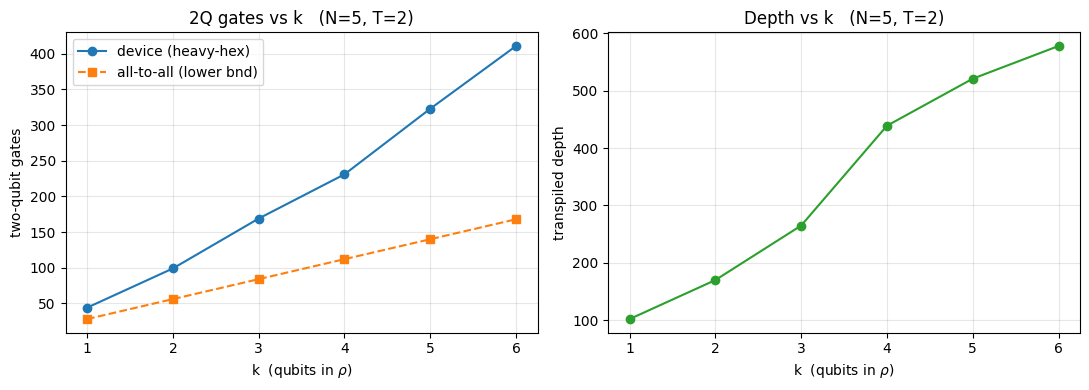

In [5]:
K_VALUES = [1, 2, 3, 4, 5, 6]
N_FIX, T_FIX = 5, 2
rows_k = []
for k in K_VALUES:
    d = measure(k, N_FIX, T_FIX, "device")
    b = measure(k, N_FIX, T_FIX, "basis")
    rows_k.append((k, d, b))
    print(f"k={k}: qubits={b['logical_qubits']:3d} | "
          f"device 2q={d['two_q_gates']:5d} depth={d['depth']:4d} total={d['total_gates']:5d} | "
          f"all2all 2q={b['two_q_gates']:5d}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(K_VALUES, [d['two_q_gates'] for _, d, _ in rows_k], 'o-', label='device (heavy-hex)')
ax[0].plot(K_VALUES, [b['two_q_gates'] for _, _, b in rows_k], 's--', label='all-to-all (lower bnd)')
ax[0].set_xlabel('k  (qubits in $\\rho$)'); ax[0].set_ylabel('two-qubit gates')
ax[0].set_title(f'2Q gates vs k   (N={N_FIX}, T={T_FIX})'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(K_VALUES, [d['depth'] for _, d, _ in rows_k], 'o-', color='C2')
ax[1].set_xlabel('k  (qubits in $\\rho$)'); ax[1].set_ylabel('transpiled depth')
ax[1].set_title(f'Depth vs k   (N={N_FIX}, T={T_FIX})'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "scaling_vs_k.png"), dpi=130); plt.show()

## Q1b — Scaling with $N$ (number of copies $\to$ amplification order $m$)

Fixing $k=2$ and $T=3$, we grow the number of copies $N$ (odd). This is the dominant driver of the
gate count: each extra pair of copies adds another swap test per round *and* lengthens the cyclic
permutation $P$, so on the heavy-hex device the routing cost grows super-linearly.

N= 3 (m-order): qubits=  7 | device 2q=   60 depth= 214 total=  401 | all2all 2q=   42
N= 5 (m-order): qubits= 12 | device 2q=  153 depth= 228 total=  961 | all2all 2q=   84
N= 7 (m-order): qubits= 17 | device 2q=  265 depth= 319 total= 1651 | all2all 2q=  126
N= 9 (m-order): qubits= 22 | device 2q=  366 depth= 511 total= 2224 | all2all 2q=  168
N=11 (m-order): qubits= 27 | device 2q=  458 depth= 458 total= 2808 | all2all 2q=  210
N=15 (m-order): qubits= 37 | device 2q=  659 depth= 505 total= 4068 | all2all 2q=  294
N=21 (m-order): qubits= 52 | device 2q=  920 depth= 473 total= 5639 | all2all 2q=  420


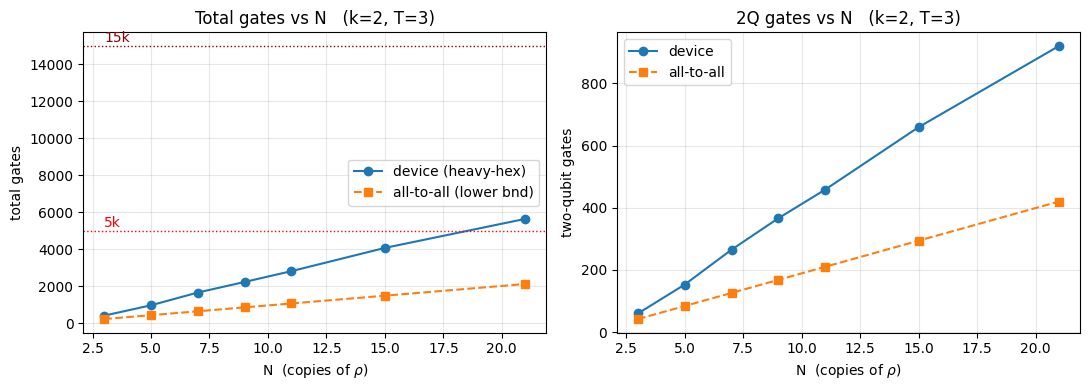

In [6]:
N_VALUES = [3, 5, 7, 9, 11, 15, 21]
K_FIX, T_FIX2 = 2, 3
rows_N = []
for N in N_VALUES:
    d = measure(K_FIX, N, T_FIX2, "device")
    b = measure(K_FIX, N, T_FIX2, "basis")
    rows_N.append((N, d, b))
    print(f"N={N:2d} (m-order): qubits={b['logical_qubits']:3d} | "
          f"device 2q={d['two_q_gates']:5d} depth={d['depth']:4d} total={d['total_gates']:5d} | "
          f"all2all 2q={b['two_q_gates']:5d}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(N_VALUES, [d['total_gates'] for _, d, _ in rows_N], 'o-', label='device (heavy-hex)')
ax[0].plot(N_VALUES, [b['total_gates'] for _, _, b in rows_N], 's--', label='all-to-all (lower bnd)')
ax[0].axhline(5000, color='r', ls=':', lw=1); ax[0].text(3, 5200, '5k', color='r')
ax[0].axhline(15000, color='darkred', ls=':', lw=1); ax[0].text(3, 15200, '15k', color='darkred')
ax[0].set_xlabel('N  (copies of $\\rho$)'); ax[0].set_ylabel('total gates')
ax[0].set_title(f'Total gates vs N   (k={K_FIX}, T={T_FIX2})'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(N_VALUES, [d['two_q_gates'] for _, d, _ in rows_N], 'o-', label='device')
ax[1].plot(N_VALUES, [b['two_q_gates'] for _, _, b in rows_N], 's--', label='all-to-all')
ax[1].set_xlabel('N  (copies of $\\rho$)'); ax[1].set_ylabel('two-qubit gates')
ax[1].set_title(f'2Q gates vs N   (k={K_FIX}, T={T_FIX2})'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "scaling_vs_N.png"), dpi=130); plt.show()

## Q1c — Scaling with $T$ (Schur-test rounds)

Fixing $k=2$ and $N=5$, we grow the number of rounds $T$. Rounds add depth and gates linearly but,
because the ancilla pool is reused, **do not add qubits** — so $T$ is the cheapest way to add
circuit volume (at the cost of depth, where decoherence bites first).

T= 1: qubits= 12 | device 2q=   40 depth=  71 total=  245 | all2all 2q=   28
T= 2: qubits= 12 | device 2q=   99 depth= 170 total=  623 | all2all 2q=   56
T= 3: qubits= 12 | device 2q=  153 depth= 228 total=  961 | all2all 2q=   84
T= 4: qubits= 12 | device 2q=  211 depth= 336 total= 1295 | all2all 2q=  112
T= 5: qubits= 12 | device 2q=  249 depth= 335 total= 1510 | all2all 2q=  140
T= 7: qubits= 12 | device 2q=  388 depth= 528 total= 2387 | all2all 2q=  196
T=10: qubits= 12 | device 2q=  558 depth= 730 total= 3370 | all2all 2q=  280


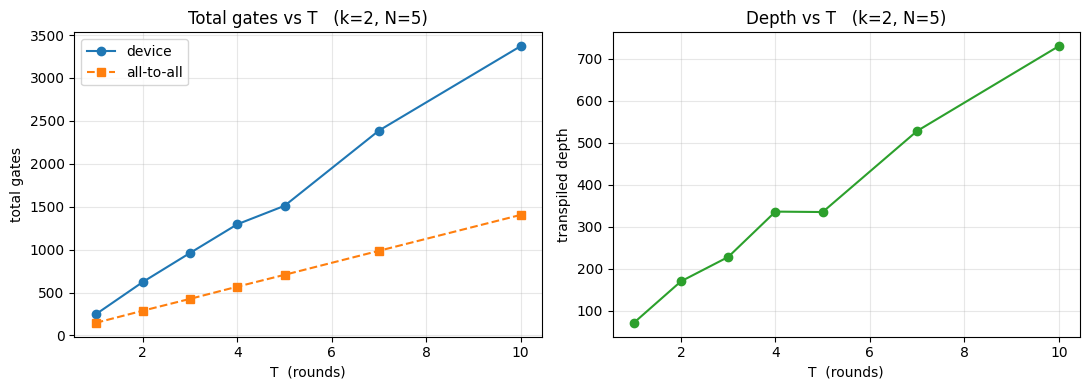

In [7]:
T_VALUES = [1, 2, 3, 4, 5, 7, 10]
K_FIX3, N_FIX3 = 2, 5
rows_T = []
for T in T_VALUES:
    d = measure(K_FIX3, N_FIX3, T, "device")
    b = measure(K_FIX3, N_FIX3, T, "basis")
    rows_T.append((T, d, b))
    print(f"T={T:2d}: qubits={b['logical_qubits']:3d} | "
          f"device 2q={d['two_q_gates']:5d} depth={d['depth']:4d} total={d['total_gates']:5d} | "
          f"all2all 2q={b['two_q_gates']:5d}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(T_VALUES, [d['total_gates'] for _, d, _ in rows_T], 'o-', label='device')
ax[0].plot(T_VALUES, [b['total_gates'] for _, _, b in rows_T], 's--', label='all-to-all')
ax[0].set_xlabel('T  (rounds)'); ax[0].set_ylabel('total gates')
ax[0].set_title(f'Total gates vs T   (k={K_FIX3}, N={N_FIX3})'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(T_VALUES, [d['depth'] for _, d, _ in rows_T], 'o-', color='C2')
ax[1].set_xlabel('T  (rounds)'); ax[1].set_ylabel('transpiled depth')
ax[1].set_title(f'Depth vs T   (k={K_FIX3}, N={N_FIX3})'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "scaling_vs_T.png"), dpi=130); plt.show()

## Q1 — The analytic cost law and the 5k–15k threshold

The all-to-all (routing-free) two-qubit count is exactly the Fredkin budget, since the permutation
SWAPs are elided:

$$ N_{2Q}^{\text{(ideal)}} \;=\; 7 \cdot \underbrace{k\,T\,\tfrac{N-1}{2}}_{\text{Fredkin gates}}
   \;=\; 3.5\,k\,T\,(N-1). $$

Linear in each of $k$, $T$, $N$. On a heavy-hex device the realized count is this times a
**routing multiplier** of $\sim2$–$3\times$ that grows with $N$ (the cyclic permutation over many
copies needs long-range SWAPs). We verify the formula and locate the 5k/15k crossings below.

In [8]:
# verify the analytic 2Q law against the all-to-all transpile
print("Check  N_2Q(ideal) = 3.5*k*T*(N-1):")
for k, N, T in [(2, 5, 1), (2, 21, 1), (4, 9, 3), (2, 5, 10)]:
    pred = 3.5 * k * T * (N - 1)
    got = measure(k, N, T, "basis")["two_q_gates"]
    print(f"  k={k} N={N:2d} T={T:2d}:  predicted={pred:7.0f}   transpiled={got:5d}")

# (N, T) scan at k=2 and k=4: where do TOTAL device gates cross 5k / 15k?
print("\nDevice total-gate scan (— = exceeds 127-qubit device):")
for k in (2, 4):
    print(f"\n  k = {k}")
    header = "    N\\T " + "".join(f"{T:>8d}" for T in (1, 2, 3, 5))
    print(header)
    for N in (3, 5, 9, 15, 21):
        cells_out = []
        for T in (1, 2, 3, 5):
            r = measure(k, N, T, "device")
            cells_out.append("       —" if r is None else f"{r['total_gates']:8d}")
        print(f"    {N:3d} " + "".join(cells_out))
print("\n(>=5000 enters the 'heavy for today' regime. 15000 IS reachable within 127 qubits at")
print(" larger subsystems, e.g. k=4, N=21, T=3 -> ~15.8k gates on 94 qubits — but at depth >1000")
print(" and >1000 two-qubit gates, i.e. deep in the noise-dominated regime for 2026 hardware.)")

Check  N_2Q(ideal) = 3.5*k*T*(N-1):
  k=2 N= 5 T= 1:  predicted=     28   transpiled=   28
  k=2 N=21 T= 1:  predicted=    140   transpiled=  140
  k=4 N= 9 T= 3:  predicted=    336   transpiled=  336
  k=2 N= 5 T=10:  predicted=    280   transpiled=  280

Device total-gate scan (— = exceeds 127-qubit device):

  k = 2
    N\T        1       2       3       5
      3      128     262     401     639
      5      245     623     961    1510
      9      490    1350    2224    3928
     15     1034    2339    4068    7239
     21     1557    3724    5639   10625

  k = 4
    N\T        1       2       3       5
      3      270     709    1065    1835
      5      530    1478    2720    4856
      9     1172    3201    5950   11290
     15     2309    6768   10563   18374
     21     3263   10257   15753   27123

(>=5000 enters the 'heavy for today' regime. 15000 IS reachable within 127 qubits at
 larger subsystems, e.g. k=4, N=21, T=3 -> ~15.8k gates on 94 qubits — but at depth >1000
 a

## Summary — answers for the reviewer

**Q2 — Are the circuits known to the gate level (can $F$ and $P$ be written in 1- and 2-qubit
gates)?**  *Yes, completely.* In OQPA's weak-Schur-sampling realization of Fig. 3:
$F = H$ (1 qubit), controlled-$P$ = controlled-SWAP / Fredkin (**7 two-qubit gates** each),
$P$ = SWAP (**3 two-qubit gates** each). Nothing is a black box; the circuits transpile directly.

**Q1 — How do depth and gate count grow with the qubits in $\rho$ ($k$) and with $m$ ($N$, $T$),
and how fast do we hit 5k–15k gates?**

* The intrinsic two-qubit count is **linear**: $N_{2Q}\approx 3.5\,k\,T\,(N-1)$. A heavy-hex device
  multiplies this by $\sim2$–$3\times$ for routing, growing with $N$.
* **The minimal $m{=}2$ demonstration ($N{=}3, T{=}1, k{=}2$) is $\sim$130 total / $\sim$20
  two-qubit gates — trivially NISQ-feasible today.** This supports the reviewer's point that for
  SQD-style applications, where classical diagonalization absorbs much of the hardware noise, an
  $m{=}2$ demonstration is the prudent target.
* The **5k-gate** regime is reached at modest sizes: $\sim$N=18–21 copies at $k{=}2, T{=}3$
  ($\sim$50 qubits), or $k{=}4, N{=}9, T{=}3$ ($\sim$40 qubits).
* **15k gates is reachable within 127 qubits, but only deep in the noise-dominated regime.** At
  $k{=}2$ the per-qubit gate density is low, so the largest device-fitting circuits top out around
  $\sim$10k total gates; reaching 15k requires larger subsystems — e.g. $k{=}4, N{=}21, T{=}3$ gives
  $\sim$15.8k total gates on **94 qubits** (fits a 127-qubit device), but with transpiled depth
  $>$1000 and $>$1000 two-qubit gates, i.e. far beyond what 2026 hardware can run with any fidelity.

**Implication for a 2026 NISQ demonstration:** a small purity-amplification demo ($m{=}2$, a
few-qubit $\rho$) is well within reach. Pushing to many copies or large $\rho$ runs into the device
qubit budget and heavy-hex routing overhead well before the gate budget alone would suggest — so
the natural target is a compact application (small $\rho$, $m{=}2$) rather than a full SQD-LUCJ
molecule. These figures also feed directly into early-FTQC resource estimates via the
$3.5\,k\,T\,(N-1)$ two-qubit law.

All plots are written to `shared_data/experiment_results/scaling/`.